## Sample-creating dataset

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-13.304687..14.880221].


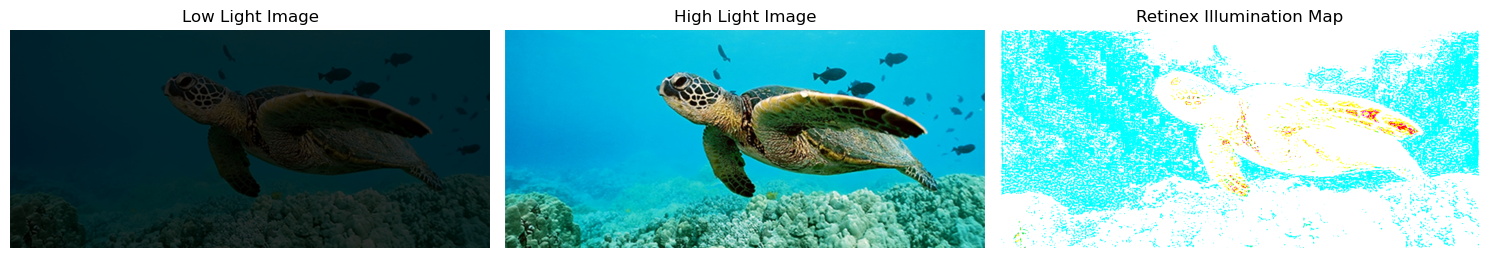

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def compute_retinex_illumination(low_img, high_img):

    low_img = low_img.astype(np.float32)+1e-5
    high_img = high_img.astype(np.float32)+1e-5

    illumination_map = np.log(high_img) - np.log(low_img)

    return illumination_map

low_img_path='L.jpg'
high_img_path='R.jpg'
low_img = cv2.imread(low_img_path, cv2.IMREAD_COLOR)
high_img = cv2.imread(high_img_path, cv2.IMREAD_COLOR)

illumination_map = compute_retinex_illumination(low_img, high_img)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(low_img, cv2.COLOR_RGB2BGR))
plt.title('Low Light Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(high_img, cv2.COLOR_RGB2BGR))
plt.title('High Light Image')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(illumination_map, cv2.COLOR_RGB2BGR))
plt.title('Retinex Illumination Map')
plt.axis('off')

plt.tight_layout()
plt.show()

## Retinex Equation

C:\Users\Vyshnav\AppData\Local\Temp\ipykernel_44104\2556295306.py:10: RuntimeWarning: divide by zero encountered in log
  log_low = np.log(low_img_float)


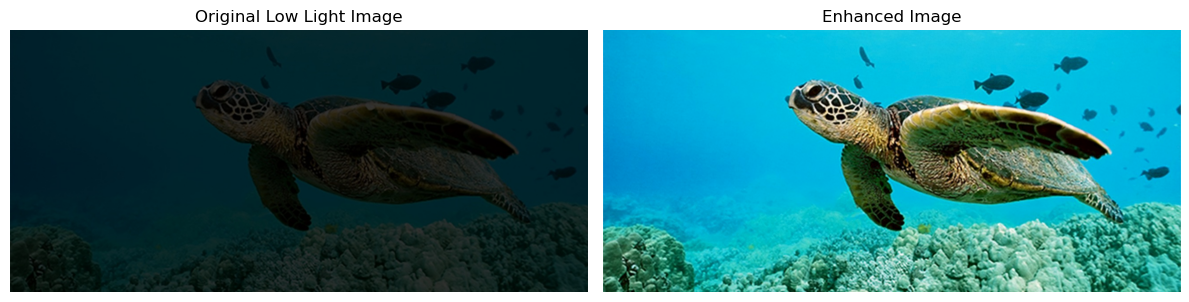

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def enhance_image_from_arrays(low_img, illumination_map):
    low_img_float = low_img.astype(np.float32) / 255.0
    illumination_map_float = illumination_map.astype(np.float32)


    log_low = np.log(low_img_float)
    log_enhanced = log_low + np.squeeze(illumination_map_float[..., np.newaxis])
    enhanced = np.exp(log_enhanced)
    enhanced = np.clip(enhanced * 255, 0, 255).astype(np.uint8)
    
    return enhanced


enhanced_img = enhance_image_from_arrays(low_img, illumination_map)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(low_img, cv2.COLOR_RGB2BGR))
plt.title('Original Low Light Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(enhanced_img, cv2.COLOR_RGB2BGR))
plt.title('Enhanced Image')
plt.axis('off')

plt.tight_layout()
plt.show()
